# 선형대수학 연습 코딩

In [1]:
print("hello")

hello


## 행렬을 표현해보자. 


In [3]:
## 형렬 연산을 위해 필요한 import들


import numpy as np
import matplotlib.pyplot as plt

In [13]:
asList = [1,2,3]
asArray = np.array(asList)
rowVec = np.array([[1,2,3]])
colVec = rowVec.T
print(f'rowVec : {rowVec.shape}')
print(f'colVec : {colVec.shape}')

rowVec : (1, 3)
colVec : (3, 1)


### 벡터의 합  

In [14]:
v = np.array([4,5,6])
w = np.array([10,20,30])
u = np.array([0,3,6])
plus = u + v + w
print(plus)

[14 28 42]


In [16]:
##this is broadcasting
v = np.array([[4,5,6]])
w = np.array([[10,20,30]])
print(v+w.T)

[[14 15 16]
 [24 25 26]
 [34 35 36]]


In [23]:
## 리스트반복과 스칼라곱

s = 2 
a = [3,4,5]
b = np.array(a)
print(a*s)
print(s*b)
print(s+b)

[3, 4, 5, 3, 4, 5]
[ 6  8 10]
[5 6 7]


### 벡터의 크기와 단위벡터 

$ \begin{Vmatrix} v \end{Vmatrix}  = \sqrt{\Sigma^n_{i=1}{v_i^2} }$

In [25]:
v = np.array([1,2,3,4,5,7,9])
v_dim = len(v)
v_mag = np.linalg.norm(v)
print(v_dim)
print(v_mag)

7
13.601470508735444


단위벡터
$ \hat{v} = \frac{1}{\begin{Vmatrix}v\end{Vmatrix}} v$


벡터의 내적 : $ \delta = \displaystyle\sum_{i=1}^{n} a_i b_i$

벡터의 내적은 두 벡터사이에 similarity (유사성)을 표현하거나 mapping의 척도로 해석할 수 있다. 
두 변수 사이에 정규화된 내적은 피어슨상관계수가 된다. 

In [27]:
v = np.array([4,5,6])
w = np.array([10,20,30])
print(np.dot(v,w))

320


분배법칙을 적용해보자.

In [28]:
a = np.array([0,1,2])
b = np.array([3,5,8])
c = np.array([13,23,22])
print(np.dot(a,b+c))
print(np.dot(a,b)+np.dot(a,c))

88
88


아다마르 곱도 계산해보자.(Hardamard product) 
A $\odot$ B

In [29]:
print(a*b)

[ 0  5 16]


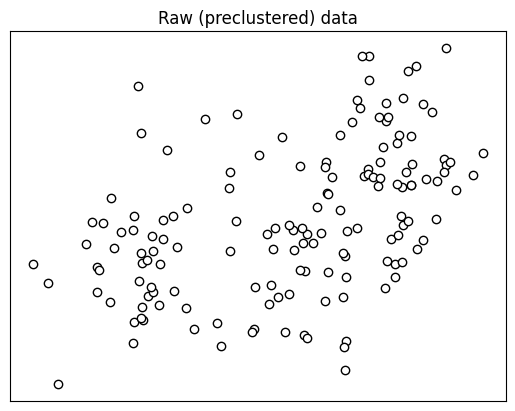

In [4]:

## Create data
nPerClust = 50

# blur around centroid (std units)
blur = 1

# XY centroid locations
A = [  1, 1 ]
B = [ -3, 1 ]
C = [  3, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# concatanate into a matrix
data = np.transpose( np.concatenate((a,b,c),axis=1) )


# plot data
plt.plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
plt.title('Raw (preclustered) data')
plt.xticks([])
plt.yticks([])

plt.show()

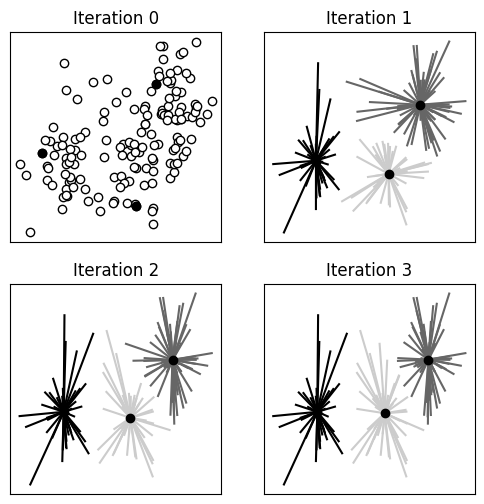

In [5]:
## initialize random cluster centroids
k = 3 # extract three clusters

# random cluster centers (randomly sampled data points)
ridx = np.random.choice(range(len(data)),k,replace=False)
centroids = data[ridx,:]


# setup the figure
fig,axs = plt.subplots(2,2,figsize=(6,6))
axs = axs.flatten()
lineColors = [ [0,0,0],[.4,.4,.4],[.8,.8,.8] ]#'rbm'


# plot data with initial random cluster centroids
axs[0].plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
axs[0].plot(centroids[:,0],centroids[:,1],'ko')
axs[0].set_title('Iteration 0')
axs[0].set_xticks([])
axs[0].set_yticks([])



# loop over iterations
for iteri in range(3):
    
  # step 1: compute distances
  dists = np.zeros((data.shape[0],k))
  for ci in range(k):
    dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis=1)
        
  # step 2: assign to group based on minimum distance
  groupidx = np.argmin(dists,axis=1)
    
  # step 3: recompute centers
  for ki in range(k):
    centroids[ki,:] = [ np.mean(data[groupidx==ki,0]), np.mean(data[groupidx==ki,1]) ]
  

  # plot data points
  for i in range(len(data)):
    axs[iteri+1].plot([ data[i,0],centroids[groupidx[i],0] ],[ data[i,1],centroids[groupidx[i],1] ],color=lineColors[groupidx[i]])
  axs[iteri+1].plot(centroids[:,0],centroids[:,1],'ko')
  axs[iteri+1].set_title(f'Iteration {iteri+1}')
  axs[iteri+1].set_xticks([])
  axs[iteri+1].set_yticks([])


plt.savefig('Figure_03_03.png',dpi=300)
plt.show()

### 연습문제 1.2 
벡터를 입력받아 Norm을 계산해보자. 이때 이 값이 np.linalg.norm()과 같은가? 

In [8]:
def myNorm(arr):
    return np.sqrt(np.sum(arr*arr))

w = np.array([1,2,1])
print(myNorm(w))
print(np.linalg.norm(w))

2.449489742783178
2.449489742783178


### 연습문제 1.3
벡터를 입력받아 단위벡터로 표현해보자. 근데, 영벡터를 넣으면 어떻게 될까? 


In [16]:
def unitVector(arr):
    return arr/myNorm(arr)

print(unitVector(w))
print(unitVector(np.zeros((4,1))))
print( myNorm(unitVector(w)))
print( myNorm(unitVector( np.zeros((4, 1)) ) ) )

[0.40824829 0.81649658 0.40824829]
[[nan]
 [nan]
 [nan]
 [nan]]
1.0
nan


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24252\2406678072.py:2: RuntimeWarning: invalid value encountered in divide
  return arr/myNorm(arr)


### 1.4 벡터와 크기를 입력하면 그 크기로 변경된 벡터를 출력하자.

In [25]:
def timeVector(arr,num):
    return num * unitVector(arr) 

print(w)
print(myNorm(w))
print(timeVector(w,5))
print(myNorm(timeVector(w,5)))

[1 2 1]
2.449489742783178
[2.04124145 4.0824829  2.04124145]
5.0


In [28]:
c = np.random.randn(5)
print(c)

norm1 = np.dot(c,c)
norm2 = myNorm(c)*myNorm(c)
print(norm1)
print(norm2)

[-0.12153675 -0.74601528 -0.60076136 -2.30724901  1.05763224]
7.374208152717851
7.374208152717852


In [32]:
n = 11

a = np.random.randn(n,1)
b = np.random.randn(n,1)

atb = np.sum(a*b)
bta = np.sum(b*a)
print(atb-bta)
print(atb)
print(np.dot(a.T,b))

0.0
1.1568154559049841
[[1.15681546]]


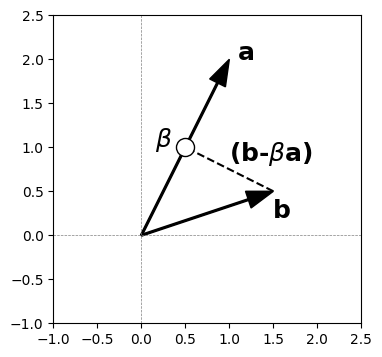

In [33]:
# the vectors a and b
a = np.array([1,2])
b = np.array([1.5,.5])

# compute beta
beta = np.dot(a,b) / np.dot(a,a)

# compute the projection vector (not explicitly used in the plot)
projvect = b - beta*a


# draw the figure
plt.figure(figsize=(4,4))

# vectors
plt.arrow(0,0,a[0],a[1],head_width=.2,width=.02,color='k',length_includes_head=True)
plt.arrow(0,0,b[0],b[1],head_width=.2,width=.02,color='k',length_includes_head=True)

# projection vector
plt.plot([b[0],beta*a[0]],[b[1],beta*a[1]],'k--')

# projection on a
plt.plot(beta*a[0],beta*a[1],'ko',markerfacecolor='w',markersize=13)

# make the plot look nicer
plt.plot([-1,2.5],[0,0],'--',color='gray',linewidth=.5)
plt.plot([0,0],[-1,2.5],'--',color='gray',linewidth=.5)

# add labels
plt.text(a[0]+.1,a[1],'a',fontweight='bold',fontsize=18)
plt.text(b[0],b[1]-.3,'b',fontweight='bold',fontsize=18)
plt.text(beta*a[0]-.35,beta*a[1],r'$\beta$',fontweight='bold',fontsize=18)
plt.text((b[0]+beta*a[0])/2,(b[1]+beta*a[1])/2+.1,r'(b-$\beta$a)',fontweight='bold',fontsize=18)

# some finishing touches
plt.axis('square')
plt.axis([-1,2.5,-1,2.5])
plt.show()